# Content Analysis — Nigeria (corpus build)

**Norman Lear Center × Gates Foundation — Manfluencer project**

This notebook assembles the **content corpus** for Nigeria that will feed the content-analysis coding pass.

Per the Nigeria selection memo (`Analysis Samples/NIGERIA - Content and Audience Analysis Samples.docx`):

| Creator | Primary platform | Pieces |
|---|---|---:|
| Banky Wellington | YouTube | **40 paragraphs** sampled across 5 transcripts (≈8 per video) |
| Deyemi Okanlawon | X | 4 posts *(memo lists 4; a 5th can be added if provided)* |
| Wizarab | X | 5 posts |
| Shola | X | 5 posts |
| Agba John Doe | X | 5 posts |

Each row has three columns — **`link`**, **`title`**, **`text`** — so Banky's transcript paragraphs and the X-creator OG tweets live in a unified schema.

**Banky transcript extraction rules:**
- Only paragraphs spoken by `Banky W (Olubankole Wellington)` — no audience lines, no Adesua, no guest speakers.
- Paragraphs with < 30 words are discarded (filler / short interjections).
- Top 8 longest remaining paragraphs per video are kept → 40 rows total.

Output is written to `Content Analysis - Nigeria/<Creator>/<Creator>_content.xlsx` plus a top-level `_summary.xlsx`.


## 0 — Setup

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
print("Project root:", ROOT)


Project root: /Users/sushildalavi/Desktop/NLC/Gates-Manfluencer-Project


## 1 — Config

In [2]:
TRANSCRIPTS_DIR = ROOT / "Generated Transcripts" / "Nigeria"
AUDIENCE_DIR = ROOT / "Nigeria Audience Comments"
OUTPUT_DIR = ROOT / "Content Analysis - Nigeria"
PLOTS_DIR = ROOT / "Content Analysis Plots - Nigeria"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

BANKY_SPEAKER = "Banky W (Olubankole Wellington)"
PARAGRAPHS_PER_VIDEO = 8
MIN_WORDS_PER_PARAGRAPH = 30

BANKY_VIDEOS = [
    {"title": "Final Say Faith - Banky & Adesua Wellington",
     "file": "Final Say Faith - Banky & Adesua Wellington.txt",
     "link": "https://www.youtube.com/watch?v=LFs0k-eluu4"},
    {"title": "My Story - a journey through Hope & Faith",
     "file": "My Story - a journey through Hope & Faith - Banky Wellington.txt",
     "link": "https://www.youtube.com/watch?v=a5PryKc1Ev8"},
    {"title": "The Prison of Pornography - Road to Freedom Finale",
     "file": "The Prison of Pornography - Road to Freedom Finale.txt",
     "link": "https://www.youtube.com/watch?v=9e9zAjM9wuA"},
    {"title": "Face it Like a Man - Banky Wellington",
     "file": "Face it Like a Man - Banky Wellington.txt",
     "link": "https://www.youtube.com/watch?v=SoVSXTTH2dg"},
    {"title": "Faith after a Fall - Banky Wellington",
     "file": "Faith after a Fall - Banky Wellington.txt",
     "link": "https://www.youtube.com/watch?v=qFHXI0jHJRM"},
]

# X posts — 5 per creator (Deyemi has 4 in the memo).
# For each post we give: (link, title/preview, creator_handle, audience_file_if_any)
# The creator-authored row from the audience file is the OG tweet text when available;
# otherwise the memo preview text is used.
X_POSTS = {
    "Deyemi Okanlawon": {
        "orientation": "Progressive",
        "handle": "_deyemi",
        "posts": [
            {"link": "https://x.com/_deyemi/status/2025894619490226565",
             "title": "Men MUST hold other men accountable... FACT!",
             "fallback": "Men MUST hold other men accountable... FACT! And 2geda we ALL shd hold ALL abusers of children, women & men accountable, fix judicial sys, destroy victim stigma, educate on consent, dismantle harmful norms. Ending rape starts with culture, not just laws #fromavictim #EndRape",
             "audience_file": "Men Must Hold Men Accountable.xlsx"},
            {"link": "https://x.com/_deyemi/status/2025896860288708660",
             "title": "When women say \"STOP rap*ng women\"…",
             "fallback": "When women say \"STOP rap*ng women\"... Your response cannot be \"what abt men/children\" neither can it be \"what abt false accusers\" nor anything else. Your reply MUST only be YES!!! You can start your own separate conversation abt anything else at another time/place. #EndRape",
             "audience_file": "Stop Raping Women Response.xlsx"},
            {"link": "https://x.com/_deyemi/status/2025962677671969172",
             "title": "Starting to see that 1 major issue is us never addressing male trauma!",
             "fallback": "Starting to see that 1 major issue is us never addressing male trauma! A lot of hurt men (some with stolen childhoods) are now either being reactive by projecting or blindly striking back. Been there n still healing so I am able to understand it. There must be a solution! 🙏🏾",
             "audience_file": None},
            {"link": "https://x.com/_deyemi/status/20259491176381360",
             "title": "LOL... I've seen the crazies on the other side…",
             "fallback": "LOL... I've seen the crazies on the other side but did not know how many crazies are on our side until now! Dear Nigerian men & women wt sense dont be distracted - stand 2geda, defend the defenceless n build a stronger society with intelligence n moral standards worth emulating!",
             "audience_file": None},
        ],
    },
    "Wizarab": {
        "orientation": "Regressive",
        "handle": "Wizarab10",
        "posts": [
            {"link": "https://x.com/Wizarab10/status/20281844110200711",
             "title": "In extra marital affair, women are the problem…",
             "fallback": "In extra marital affair, women are the problem either as the side chic or the married person.",
             "audience_file": None},
            {"link": "https://x.com/Wizarab10/status/20276692910598554",
             "title": "Before the advent of sex toys, women got off by raping young boys…",
             "fallback": "Before the advent of sex toys, women got off by raping young boys when they were horny.",
             "audience_file": "Sex Toys and Raping Young Boys.xlsx"},
            {"link": "https://x.com/Wizarab10/status/20308926907667255",
             "title": "Child support is fraudulent",
             "fallback": "When you were with the kids, he was paying child support... This brings me to my argument that the concept of child support is fraudulent.",
             "audience_file": "Child Support and Divorce.xlsx"},
            {"link": "https://x.com/Wizarab10/status/20294818211555002",
             "title": "Take you serious if you don't spend on me",
             "fallback": "Na me go take you serious if you don't spend on me and make my life easier?",
             "audience_file": None},
            {"link": "https://x.com/Wizarab10/status/20312647424807530",
             "title": "Men don't pick women the way women pick men",
             "fallback": "LOL. Yes. Men don't pick women the way women pick men.",
             "audience_file": None},
        ],
    },
    "Shola": {
        "orientation": "Regressive",
        "handle": "itsSh0la",
        "posts": [
            {"link": "https://x.com/itsSh0la/status/18512163035639071",
             "title": "Men are in love, women are in business",
             "fallback": "Men are in love, women are in business.",
             "audience_file": None},
            {"link": "https://x.com/itsSh0la/status/20314429899820894",
             "title": "They will teach themselves everything except how to keep a home…",
             "fallback": "They will teach themselves everything except how to keep a home, remain submissive, and stay faithful.",
             "audience_file": None},
            {"link": "https://x.com/itsSh0la/status/20305626486563352",
             "title": "7 women will desperately beg one man to marry them",
             "fallback": "We are slowly entering the era where 7 women will desperately beg one man to marry them.",
             "audience_file": "7 Women Will Beg One Man to Marry.xlsx"},
            {"link": "https://x.com/itsSh0la/status/20295337062815006",
             "title": "I laugh whenever women say I was there for him when he had nothing",
             "fallback": "This is why I laugh whenever women say I was there for him when he had nothing.",
             "audience_file": None},
            {"link": "https://x.com/itsSh0la/status/17702467250950270",
             "title": "Nigerian Church Girls as Red Flags",
             "fallback": "Nigerian Church Girls as Red Flags.",
             "audience_file": None},
        ],
    },
    "Agba John Doe": {
        "orientation": "Regressive",
        "handle": "jon_d_doe",
        "posts": [
            {"link": "https://x.com/jon_d_doe/status/15567399088108175",
             "title": "Never be too quick to leave your marriage because your husband cheated",
             "fallback": "For married women, never be too quick to leave your marriage because your husband cheated.",
             "audience_file": "Never Leave Marriage Because Husband Cheated.xlsx"},
            {"link": "https://x.com/jon_d_doe/status/20310864507085417",
             "title": "Most women who do BBL are doing it to prostitute their bodies",
             "fallback": "Most women who do BBL are doing it because they want to prostitute their bodies at a higher price.",
             "audience_file": None},
            {"link": "https://x.com/jon_d_doe/status/20292112731838098",
             "title": "Any single woman earning above N1.5m per month is likely over 30",
             "fallback": "Any single woman in today's Nigeria who earns above N1.5m per month is likely to be over 30 years old.",
             "audience_file": "Single Woman Earning Above 1.5M.xlsx"},
            {"link": "https://x.com/jon_d_doe/status/20303481982466009",
             "title": "A woman that has committed 20 abortions will most likely get married before a single mother",
             "fallback": "A woman that has committed 20 abortions will most likely get married before a single mother that has committed no abortion.",
             "audience_file": None},
            {"link": "https://x.com/jon_d_doe/status/20332426465341400",
             "title": "Elder sisters unmarried / divorced / single mothers — rethink",
             "fallback": "If the man that wants to marry you has elder sisters that are either unmarried, divorced or single mothers, please rethink your decision.",
             "audience_file": None},
        ],
    },
}

for creator, meta in X_POSTS.items():
    print(f"  {creator:<20} [{meta['orientation']}] {len(meta['posts'])} posts")
print()
print(f"Banky transcripts: {len(BANKY_VIDEOS)} videos -> target {PARAGRAPHS_PER_VIDEO * len(BANKY_VIDEOS)} paragraphs")


  Deyemi Okanlawon     [Progressive] 4 posts
  Wizarab              [Regressive] 5 posts
  Shola                [Regressive] 5 posts
  Agba John Doe        [Regressive] 5 posts

Banky transcripts: 5 videos -> target 40 paragraphs


## 2 — Extract Banky paragraphs

Parse each transcript, keep only turns spoken by Banky, drop anything under 30 words, then pick the 8 longest per video.


In [3]:
TARGET_CHUNK_WORDS = 200  # for long Banky monologues, re-chunk at sentence boundaries


def _split_long_turn(content, target_words=TARGET_CHUNK_WORDS):
    # Prefer sentence boundaries when present; otherwise fall back to word-window chunks
    # (many transcripts have no sentence punctuation from raw ASR).
    words = content.strip().split()
    if not words:
        return []
    sentences = re.split(r"(?<=[.!?])\s+", content.strip())
    # If splitting on sentences produced any chunk > 2x target, fall back to pure word windows.
    sentence_too_long = any(len(s.split()) > target_words * 2 for s in sentences)
    if len(sentences) <= 1 or sentence_too_long:
        chunks = []
        for start in range(0, len(words), target_words):
            chunk_words = words[start:start + target_words]
            if len(chunk_words) >= MIN_WORDS_PER_PARAGRAPH:
                chunks.append(" ".join(chunk_words))
        return chunks

    chunks, current, current_words = [], [], 0
    for s in sentences:
        w = len(s.split())
        if current_words + w > target_words and current:
            chunks.append(" ".join(current).strip())
            current, current_words = [], 0
        current.append(s)
        current_words += w
    if current:
        chunks.append(" ".join(current).strip())
    return [c for c in chunks if c]


def parse_banky_paragraphs(path, banky_label=BANKY_SPEAKER):
    text = Path(path).read_text(encoding="utf-8")
    # Strip the header block (title / stats / speaker line) — first blank line separates it from body.
    body_parts = re.split(r"\n\s*\n", text, maxsplit=1)
    body = body_parts[1] if len(body_parts) == 2 else text
    turns = [t.strip() for t in re.split(r"\n\s*\n", body) if t.strip()]

    paragraphs = []
    for turn in turns:
        m = re.match(r"^([^:\n]{2,120}):\s*(.+)$", turn, flags=re.DOTALL)
        if not m:
            continue
        speaker, content = m.group(1).strip(), m.group(2).strip()
        if speaker != banky_label:
            continue
        content = re.sub(r"\s+", " ", content).strip()
        if not content:
            continue
        # If the turn itself is long, re-chunk at sentence boundaries.
        if len(content.split()) > TARGET_CHUNK_WORDS * 1.5:
            pieces = _split_long_turn(content)
        else:
            pieces = [content]
        for piece in pieces:
            nw = len(piece.split())
            if nw < MIN_WORDS_PER_PARAGRAPH:
                continue
            paragraphs.append({"text": piece, "n_words": nw})
    return pd.DataFrame(paragraphs)


banky_rows = []
for video in BANKY_VIDEOS:
    path = TRANSCRIPTS_DIR / video["file"]
    paras = parse_banky_paragraphs(path)
    top = paras.sort_values("n_words", ascending=False).head(PARAGRAPHS_PER_VIDEO)
    print(f"  {video['title'][:50]:<50}  total_banky_paras={len(paras):>3}  kept={len(top)}")
    for _, r in top.iterrows():
        banky_rows.append({
            "creator": "Banky Wellington",
            "orientation": "Progressive",
            "link": video["link"],
            "title": video["title"],
            "text": r["text"],
            "n_words": int(r["n_words"]),
        })

banky_df = pd.DataFrame(banky_rows)
print()
print(f"Banky rows total: {len(banky_df)}")
print(f"Word-count distribution -- min: {banky_df['n_words'].min()}, median: {int(banky_df['n_words'].median())}, max: {banky_df['n_words'].max()}")
banky_df.head(3)


  Final Say Faith - Banky & Adesua Wellington         total_banky_paras= 46  kept=8
  My Story - a journey through Hope & Faith           total_banky_paras= 50  kept=8
  The Prison of Pornography - Road to Freedom Finale  total_banky_paras= 58  kept=8
  Face it Like a Man - Banky Wellington               total_banky_paras= 58  kept=8
  Faith after a Fall - Banky Wellington               total_banky_paras= 41  kept=8

Banky rows total: 40
Word-count distribution -- min: 197, median: 200, max: 289


,creator,orientation,link,title,text,n_words
0,Banky Wellington,Progressive,https://www.youtube.com/watch?v=LFs0k-eluu4,Final Say Faith - Banky & Adesua Wellington,me i come with some radical idea you know me i...,255
1,Banky Wellington,Progressive,https://www.youtube.com/watch?v=LFs0k-eluu4,Final Say Faith - Banky & Adesua Wellington,of this to say it's not we're not saying that ...,214
2,Banky Wellington,Progressive,https://www.youtube.com/watch?v=LFs0k-eluu4,Final Say Faith - Banky & Adesua Wellington,was the cutest little boy and i saw a bit of h...,201


## 3 — Assemble X-creator posts

For each X post: prefer the OG tweet text extracted from the audience dataset (creator-authored row). If the post isn't in our audience data, fall back to the preview text from the selection memo.


In [4]:
def fetch_og_from_audience(creator, handle, audience_file):
    path = AUDIENCE_DIR / creator / audience_file
    if not path.exists():
        return None
    df = pd.read_excel(path)
    text_col = "text" if "text" in df.columns else ("comment" if "comment" in df.columns else None)
    if text_col is None or "author" not in df.columns:
        return None
    op_rows = df[df["author"].astype(str).str.lower() == handle.lower()]
    if op_rows.empty:
        return None
    # Some posts are threads — concatenate in order.
    texts = [str(t).strip() for t in op_rows[text_col].tolist() if isinstance(t, str) and str(t).strip()]
    if not texts:
        return None
    joined = " ".join(texts)
    return re.sub(r"\s+", " ", joined).strip()


x_rows = []
for creator, meta in X_POSTS.items():
    for p in meta["posts"]:
        text = None
        source = "memo_fallback"
        if p["audience_file"]:
            text = fetch_og_from_audience(creator, meta["handle"], p["audience_file"])
            if text:
                source = "audience_og"
        if not text:
            text = p["fallback"]
        x_rows.append({
            "creator": creator,
            "orientation": meta["orientation"],
            "link": p["link"],
            "title": p["title"],
            "text": text,
            "n_words": len(text.split()),
            "text_source": source,
        })

x_df = pd.DataFrame(x_rows)
src_counts = x_df["text_source"].value_counts()
print("Text sources for X posts:")
print(src_counts.to_string())
print()
print(f"X rows total: {len(x_df)}")
x_df[["creator", "title", "n_words", "text_source"]]


Text sources for X posts:


text_source
memo_fallback    13
audience_og       6

X rows total: 19


,creator,title,n_words,text_source
0,Deyemi Okanlawon,Men MUST hold other men accountable... FACT!,43,memo_fallback
1,Deyemi Okanlawon,"When women say ""STOP rap*ng women""…",44,audience_og
2,Deyemi Okanlawon,Starting to see that 1 major issue is us never...,51,memo_fallback
3,Deyemi Okanlawon,LOL... I've seen the crazies on the other side…,50,memo_fallback
4,Wizarab,"In extra marital affair, women are the problem…",17,memo_fallback
5,Wizarab,"Before the advent of sex toys, women got off b...",36,audience_og
6,Wizarab,Child support is fraudulent,62,audience_og
7,Wizarab,Take you serious if you don't spend on me,17,memo_fallback
8,Wizarab,Men don't pick women the way women pick men,11,memo_fallback
9,Shola,"Men are in love, women are in business",8,memo_fallback


## 4 — Unified corpus

In [5]:
corpus = pd.concat([banky_df.assign(text_source="transcript"), x_df], ignore_index=True)
corpus["piece_id"] = range(1, len(corpus) + 1)
corpus = corpus[["piece_id", "creator", "orientation", "link", "title", "text", "n_words", "text_source"]]

summary = (corpus.groupby(["creator", "orientation"])
           .agg(pieces=("piece_id", "count"),
                median_words=("n_words", "median"),
                min_words=("n_words", "min"),
                max_words=("n_words", "max"))
           .reset_index()
           .sort_values("orientation"))
print(f"Total corpus rows: {len(corpus)}")
summary


Total corpus rows: 59


,creator,orientation,pieces,median_words,min_words,max_words
1,Banky Wellington,Progressive,40,200.0,197,289
2,Deyemi Okanlawon,Progressive,4,47.0,43,51
0,Agba John Doe,Regressive,5,23.0,19,488
3,Shola,Regressive,5,16.0,6,36
4,Wizarab,Regressive,5,17.0,11,62


## 5 — Export

In [6]:
def _safe(name):
    return re.sub(r"[^\w\- ]+", "", name).strip()


summary_rows = []
for (creator, orientation), g in corpus.groupby(["creator", "orientation"]):
    creator_dir = OUTPUT_DIR / _safe(creator)
    creator_dir.mkdir(parents=True, exist_ok=True)
    out_path = creator_dir / f"{_safe(creator)}_content.xlsx"
    # User-requested columns only: link, title, text.
    out = g[["link", "title", "text"]].reset_index(drop=True)
    out.to_excel(out_path, index=False)
    summary_rows.append({
        "creator": creator,
        "orientation": orientation,
        "pieces": len(out),
        "path": str(out_path.relative_to(ROOT)),
    })

corpus_summary = pd.DataFrame(summary_rows)
(OUTPUT_DIR / "_summary.xlsx").write_bytes(b"")  # ensure file exists before pandas writes
corpus_summary.to_excel(OUTPUT_DIR / "_summary.xlsx", index=False)

# Also keep a full unified view with all metadata for downstream coding.
corpus.to_excel(OUTPUT_DIR / "_corpus_full.xlsx", index=False)

print(f"Wrote {len(summary_rows)} per-creator files + _summary.xlsx + _corpus_full.xlsx to {OUTPUT_DIR}")
corpus_summary


Wrote 5 per-creator files + _summary.xlsx + _corpus_full.xlsx to /Users/sushildalavi/Desktop/NLC/Gates-Manfluencer-Project/Content Analysis - Nigeria


,creator,orientation,pieces,path
0,Agba John Doe,Regressive,5,Content Analysis - Nigeria/Agba John Doe/Agba ...
1,Banky Wellington,Progressive,40,Content Analysis - Nigeria/Banky Wellington/Ba...
2,Deyemi Okanlawon,Progressive,4,Content Analysis - Nigeria/Deyemi Okanlawon/De...
3,Shola,Regressive,5,Content Analysis - Nigeria/Shola/Shola_content...
4,Wizarab,Regressive,5,Content Analysis - Nigeria/Wizarab/Wizarab_con...


## 6 — Report plots

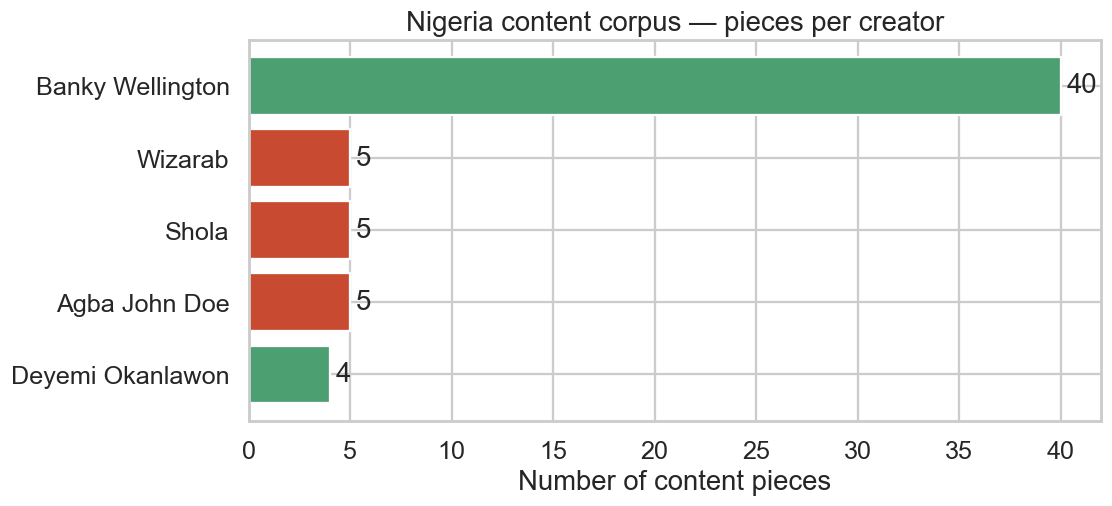

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
order = corpus_summary.sort_values("pieces", ascending=True)
colors = ["#4C9F70" if o == "Progressive" else "#C84B31" for o in order["orientation"]]
ax.barh(order["creator"], order["pieces"], color=colors)
for i, n in enumerate(order["pieces"]):
    ax.text(n + 0.3, i, str(n), va="center")
ax.set_title("Nigeria content corpus — pieces per creator")
ax.set_xlabel("Number of content pieces")
plt.savefig(PLOTS_DIR / "01_pieces_per_creator.png")
plt.show()


/var/folders/dv/4yw53xh14jg0_mcrwc977cgm0000gn/T/ipykernel_91183/1044811783.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=corpus, y="creator", x="n_words", ax=ax, palette="Blues")


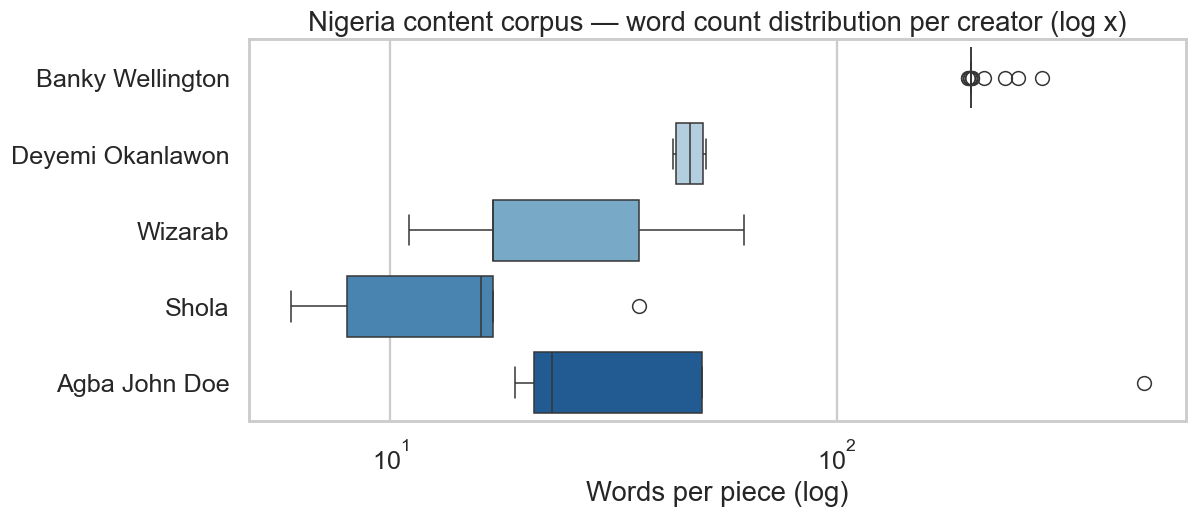

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(data=corpus, y="creator", x="n_words", ax=ax, palette="Blues")
ax.set_xscale("log")
ax.set_title("Nigeria content corpus — word count distribution per creator (log x)")
ax.set_xlabel("Words per piece (log)")
ax.set_ylabel("")
plt.savefig(PLOTS_DIR / "02_word_counts.png")
plt.show()


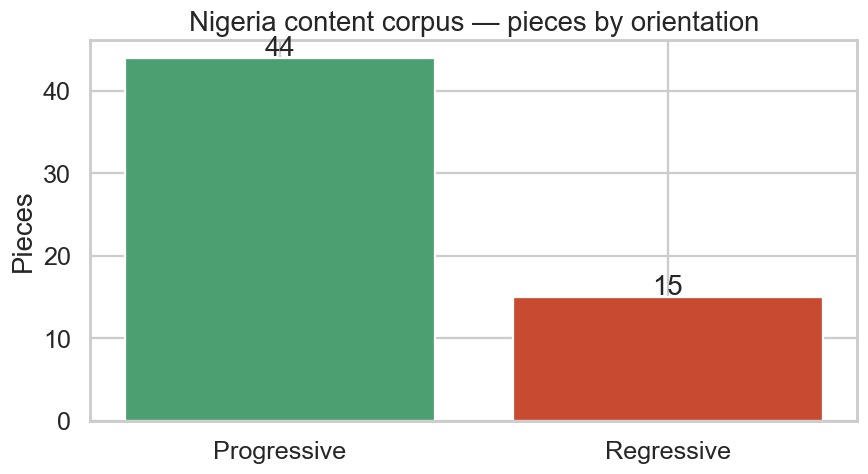

,orientation,pieces,total_words,avg_words
0,Progressive,44,8378,190.409091
1,Regressive,15,827,55.133333


In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
by_orient = corpus.groupby("orientation").agg(
    pieces=("piece_id", "count"),
    total_words=("n_words", "sum"),
    avg_words=("n_words", "mean")
).reset_index()
x = range(len(by_orient))
ax.bar(x, by_orient["pieces"], color=["#4C9F70", "#C84B31"])
for i, n in enumerate(by_orient["pieces"]):
    ax.text(i, n + 0.3, str(n), ha="center")
ax.set_xticks(x)
ax.set_xticklabels(by_orient["orientation"])
ax.set_title("Nigeria content corpus — pieces by orientation")
ax.set_ylabel("Pieces")
plt.savefig(PLOTS_DIR / "03_orientation_split.png")
plt.show()
by_orient


## 7 — Next step (out of scope for this notebook)

With the corpus built, the next step is coding each piece against the Gates codebook (attention-getting strategies, masculinity norms, primary topics, problems/solutions, sentiment, etc.). That is a separate notebook that will read `_corpus_full.xlsx`, call `gpt-4o` with a structured-JSON prompt, and write labeled outputs for analysis.

## Notes

- Banky extraction is deterministic: top-8 longest Banky-spoken paragraphs per video, minimum 30 words. Re-running yields the same 40 paragraphs.
- X-post text prefers the audience-data OG row when available (5 of 19); otherwise uses the memo preview text.
- Deyemi only has 4 posts in the memo — add a 5th link here to bring him up to 5.
